<a href="https://colab.research.google.com/github/aboodi320/smart-waste-ocl/blob/dev/MobilnetV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub tqdm scikit-learn

import tensorflow as tf
print("TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("GPU:", "YES" if gpus else "NO")

TensorFlow: 2.19.0
GPU: YES


We downloaded the TrashNET dataset from Kaggle using the kagglehub library.

In [2]:
import kagglehub

path = kagglehub.dataset_download("zlatan599/garbage-dataset-classification")
print("Path to dataset files:", path)

100%|██████████| 121M/121M [00:07<00:00, 17.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zlatan599/garbage-dataset-classification/versions/5


The main purpose here was to show how many samples were taken from each category and to display the total number of samples in the dataset.

In [4]:
from pathlib import Path

BASE = Path("/root/.cache/kagglehub/datasets/zlatan599/garbage-dataset-classification/versions/5/Garbage_Dataset_Classification/images")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp"}

def count_images(folder: Path, recursive: bool = False) -> int:
    if recursive:
        return sum(1 for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
    else:
        return sum(1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS)

if not BASE.exists():
    raise FileNotFoundError(f"file not found: {BASE}")

class_dirs = sorted([d for d in BASE.iterdir() if d.is_dir()])
total = 0

print(f"Base file: {BASE}\n")

for d in class_dirs:
    n = count_images(d, recursive=False)
    total += n
    print(f"{d.name:<12}: {n:5d}")

print("-" * 24)
print(f"{'sum':<12}: {total:5d}")

Base file: /root/.cache/kagglehub/datasets/zlatan599/garbage-dataset-classification/versions/5/Garbage_Dataset_Classification/images

cardboard   :  2214
glass       :  2500
metal       :  2084
paper       :  2315
plastic     :  2288
trash       :  2500
------------------------
sum         : 13901


We split the selected classes into training, validation, and test sets with ratios of 70%, 15%, and 15%.

In [5]:
import os
import shutil
import random
import numpy as np

random.seed(42)
np.random.seed(42)

SOURCE_DIR = str(BASE)
DEST_DIR = "/content/garbage_split"

SELECTED_CLASSES = ["cardboard", "glass", "metal", "paper", "plastic"]

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

print("Using classes:", SELECTED_CLASSES)

for cls in SELECTED_CLASSES:
    cls_path = os.path.join(SOURCE_DIR, cls)

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    random.shuffle(images)

    n = len(images)
    train_end = int(n * TRAIN_RATIO)
    val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, files in splits.items():
        split_dir = os.path.join(DEST_DIR, split, cls)
        os.makedirs(split_dir, exist_ok=True)

        for file in files:
            shutil.copy(
                os.path.join(cls_path, file),
                os.path.join(split_dir, file)
            )

    print(
        f"{cls:<10} : "
        f"Train: {len(splits['train'])}, "
        f"Val: {len(splits['val'])}, "
        f"Test: {len(splits['test'])}"
    )

Using classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic']
cardboard  : Train: 1549, Val: 332, Test: 333
glass      : Train: 1750, Val: 375, Test: 375
metal      : Train: 1458, Val: 313, Test: 313
paper      : Train: 1620, Val: 347, Test: 348
plastic    : Train: 1601, Val: 343, Test: 344


In this stage, the preprocessing and data augmentation steps to be applied to the image data were defined.
It was specified that the images would be resized to 224×224, normalized to the [-1, 1] range using the MobileNetV3-specific preprocess_input function, and that the batch size would be set to 32.
In addition, the data loading and processing strategies for the training, validation, and test datasets were configured using the ImageDataGenerator.

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN_DIR = f"{DEST_DIR}/train"
VAL_DIR   = f"{DEST_DIR}/val"
TEST_DIR  = f"{DEST_DIR}/test"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In this step, data generators were created for the training, validation, and test sets using the previously defined preprocessing and augmentation rules.
Training data was shuffled and augmented, while validation and test data were only preprocessed.
Finally, the number of classes and class names were extracted from the training data.

In [7]:
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

val_data = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
CLASS_NAMES = list(train_data.class_indices.keys())

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)
print("Train samples:", train_data.samples)
print("Val samples:", val_data.samples)
print("Test samples:", test_data.samples)

Found 7978 images belonging to 5 classes.
Found 1710 images belonging to 5 classes.
Found 1713 images belonging to 5 classes.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic']
Number of classes: 5
Train samples: 7978
Val samples: 1710
Test samples: 1713


In this here a transfer learning approach was applied using the ImageNet-pretrained MobileNetV3Large model as the base network. The base model’s weights were frozen, and custom classification layers were added on top. The model was then compiled with the Adam optimizer and categorical cross-entropy loss, making it ready for training.

In [8]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV3Large(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

model.summary()

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,279,749 (12.51 MB)

 Trainable params: 281,477 (1.07 MB)

 Non-trainable params: 2,998,272 (11.44 MB)

In this step, the model was trained using training and validation data with callback mechanisms to control and optimize the training process.
ModelCheckpoint, EarlyStopping, and ReduceLROnPlateau were used to save the best model, prevent overfitting, and adjust the learning rate dynamically

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks_stage1 = [
    ModelCheckpoint(
        "mobilenetv3_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks_stage1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.4130 - loss: 1.5381
Epoch 1: val_accuracy improved from -inf to 0.81696, saving model to mobilenetv3_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 161s 538ms/step - accuracy: 0.4135 - loss: 1.5369 - val_accuracy: 0.8170 - val_loss: 0.6815 - learning_rate: 1.0000e-04
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.7311 - loss: 0.8597
Epoch 2: val_accuracy improved from 0.81696 to 0.87836, saving model to mobilenetv3_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 96s 382ms/step - accuracy: 0.7311 - loss: 0.8596 - val_accuracy: 0.8784 - val_loss: 0.5652 - learning_rate: 1.0000e-04
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.7853 - loss: 0.7273
Epoch 3: val_accuracy improved from 0.87836 to 0.88421, saving model to mobilenetv3_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 95s 380ms/step - accuracy: 0.7853 - loss: 0.7273 - val_accuracy: 0.8842 - val_loss: 0.5300 - learning_rate: 1.0000e-04
Epoch 4/3

In this stage, fine-tuning training was performed.
The last 50 layers of the MobileNetV3 base model were unfrozen, while the earlier layers remained frozen to preserve previously learned features.
The model was retrained using a smaller learning rate to allow more stable and controlled updates.
The same callback mechanisms were used to prevent overfitting and to save the best-performing model based on validation performance.

In [11]:
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9655 - loss: 0.3515
Test Loss: 0.3667326271533966
Test Accuracy: 0.9591360092163086


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# MobileNet katmanlarını aç
base_model.trainable = True

# sadece son 50 katmanı eğit
for layer in base_model.layers[:-50]:
    layer.trainable = False

# yeniden compile
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

callbacks_stage2 = [
    ModelCheckpoint(
        "mobilenetv3_finetuned_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks_stage2,
    verbose=1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8945 - loss: 0.5015
Epoch 1: val_accuracy improved from -inf to 0.94678, saving model to mobilenetv3_finetuned_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 468ms/step - accuracy: 0.8945 - loss: 0.5015 - val_accuracy: 0.9468 - val_loss: 0.3952 - learning_rate: 1.0000e-05
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9041 - loss: 0.4801
Epoch 2: val_accuracy did not improve from 0.94678
250/250 ━━━━━━━━━━━━━━━━━━━━ 94s 377ms/step - accuracy: 0.9042 - loss: 0.4800 - val_accuracy: 0.9450 - val_loss: 0.3966 - learning_rate: 1.0000e-05
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9216 - loss: 0.4463
Epoch 3: val_accuracy did not improve from 0.94678
250/250 ━━━━━━━━━━━━━━━━━━━━ 94s 375ms/step - accuracy: 0.9216 - loss: 0.4463 - val_accuracy: 0.9450 - val_loss: 0.3949 - learning_rate: 1.0000e-05
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9235 - loss: 0.4430

In [13]:
test_loss, test_acc = model.evaluate(test_data, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.9714 - loss: 0.3337
Test Loss: 0.350408673286438
Test Accuracy: 0.9649737477302551


Since the model accuracy showed a consistent improvement during the previous 40 epochs, an additional experiment was conducted using a smaller learning rate and fewer epochs to test whether further improvements were possible.
However, this short training stage did not lead to a significant performance gain, and the accuracy did not increase noticeably.

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Son katmanları aç
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False


callbacks_stage3 = [
    ModelCheckpoint(
        "mobilenetv3_final_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

model.compile(
    optimizer=Adam(3e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

history3 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks_stage3,
    verbose=1
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.9646 - loss: 0.3591
Epoch 1: val_accuracy improved from -inf to 0.95556, saving model to mobilenetv3_final_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 131s 453ms/step - accuracy: 0.9646 - loss: 0.3591 - val_accuracy: 0.9556 - val_loss: 0.3600 - learning_rate: 3.0000e-06
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9654 - loss: 0.3541
Epoch 2: val_accuracy improved from 0.95556 to 0.95614, saving model to mobilenetv3_final_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 96s 382ms/step - accuracy: 0.9654 - loss: 0.3541 - val_accuracy: 0.9561 - val_loss: 0.3601 - learning_rate: 3.0000e-06
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9699 - loss: 0.3486
Epoch 3: val_accuracy did not improve from 0.95614
250/250 ━━━━━━━━━━━━━━━━━━━━ 96s 382ms/step - accuracy: 0.9699 - loss: 0.3486 - val_accuracy: 0.9556 - val_loss: 0.3598 - learning_rate: 3.0000e-06
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0

In [15]:
best_model = tf.keras.models.load_model("mobilenetv3_final_best.keras")

test_loss, test_acc = best_model.evaluate(test_data, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.9736 - loss: 0.3320
Test Loss: 0.3497234284877777
Test Accuracy: 0.9649737477302551


In [17]:
best_model = tf.keras.models.load_model("mobilenetv3_finetuned_best.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("mobilenetv3_finetuned_best.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model kaydedildi: mobilenetv3_finetuned_best.tflite")

Saved artifact at '/tmp/tmpclsmv2ve'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138700715407888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138700715406928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138700715407120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138700715407504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138700715409232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138700715408272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138700715406736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138700715399632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138700715408080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138700715406160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138700715408848

In [18]:
from google.colab import files
files.download("mobilenetv3_finetuned_best.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

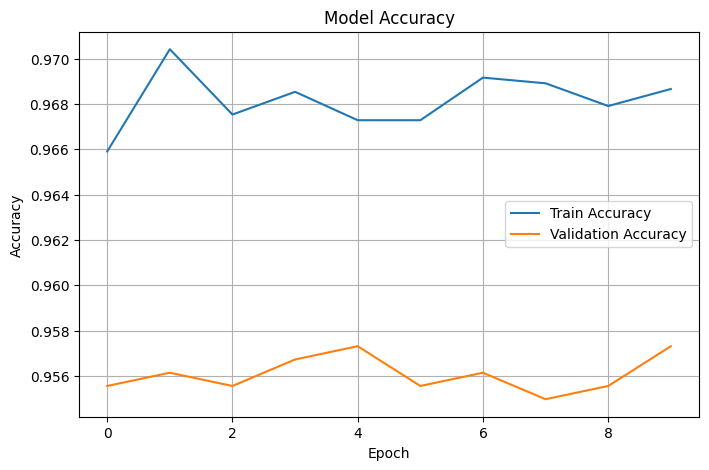

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

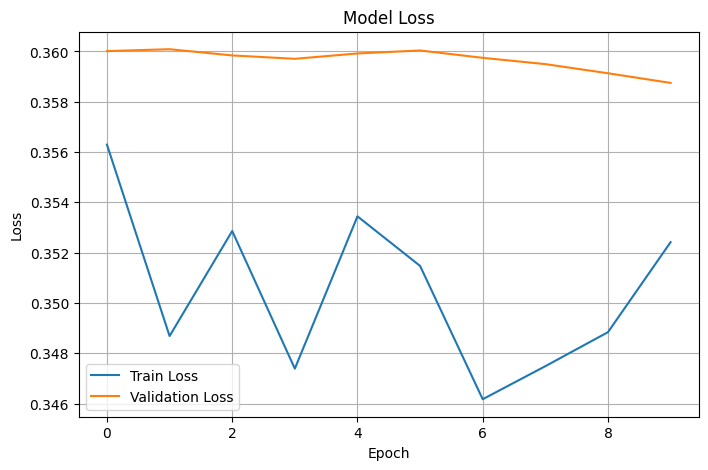

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

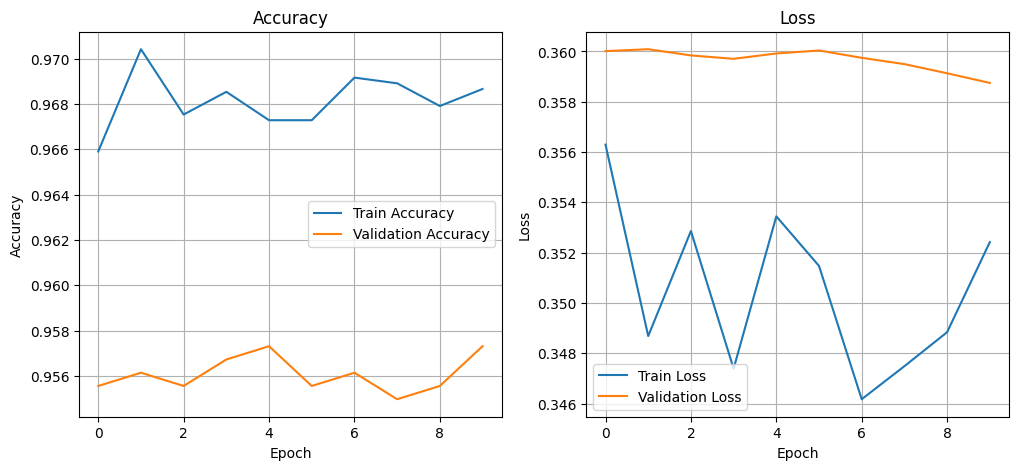

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [22]:
import numpy as np

best_model = tf.keras.models.load_model("mobilenetv3_finetuned_best.keras")

predictions = best_model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9643899591360187
Precision: 0.9646108314526878
Recall: 0.9643899591360187
F1 Score: 0.9642995622879827


In [24]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

   cardboard       0.97      0.96      0.97       333
       glass       0.97      0.97      0.97       375
       metal       0.94      0.99      0.96       313
       paper       0.97      0.98      0.98       348
     plastic       0.97      0.92      0.95       344

    accuracy                           0.96      1713
   macro avg       0.96      0.96      0.96      1713
weighted avg       0.96      0.96      0.96      1713



In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[320   1   4   4   4]
 [  1 364   5   0   5]
 [  0   1 309   1   2]
 [  4   0   3 341   0]
 [  4  11   7   4 318]]


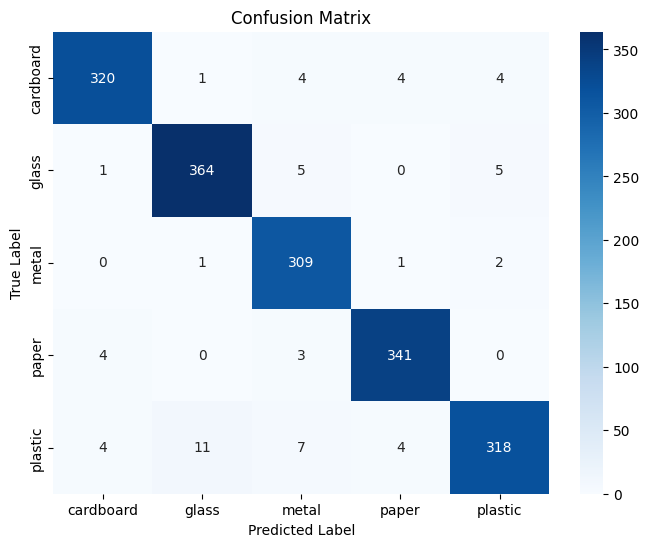

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [28]:
best_model.save("garbage_classifier.keras")

print("Model .keras formatında kaydedildi")
files.download("garbage_classifier.keras")

Model .keras formatında kaydedildi


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>